# Analyzing the Impact of Shooting and Minutes on Player Scoring

**DAP Mini Project**

**Author:** Asmit Yadav
**Date:** 18 November 2025

---

This notebook walks through data loading, cleaning, EDA, hypothesis testing, and regression modeling for predicting player points using regular season statistics.

## Setup and Dataset


**Dataset**: `Regular_Season.csv`. If automatic checks fail, please place `Regular_Season.csv` into the same folder as this notebook.

**Kaggle Link**: https://www.kaggle.com/datasets/shivamkumar121215/nba-stats-dataset-for-last-10-years/data?select=Regular_Season.csv

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
sns.set(style='whitegrid')
pd.set_option('display.max_columns', 120)

In [29]:
csv_path = Path('Regular_Season.csv')
if not csv_path.exists():
    print('Please download the dataset manually and save as "Regular_Season.csv" in this folder.')
else:
    print('Regular_Season.csv found in the working directory.')

Regular_Season.csv found in the working directory.


In [30]:
df = pd.read_csv('Regular_Season.csv')
print('Loaded dataset with shape:', df.shape)
display(df.head())

Loaded dataset with shape: (6259, 31)


,Unnamed: 0.1,Unnamed: 0,year,Season_type,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,AST_TOV,STL_TOV
0,0,0,2012-13,Regular_Season,201142,1,Kevin Durant,1610612760,OKC,81,3119,731,1433,0.510,139,334,0.416,679,750,0.905,46,594,640,374,116,105,280,143,2280,1.34,0.41
1,1,1,2012-13,Regular_Season,977,2,Kobe Bryant,1610612747,LAL,78,3013,738,1595,0.463,132,407,0.324,525,626,0.839,66,367,433,469,106,25,287,173,2133,1.63,0.37
2,2,2,2012-13,Regular_Season,2544,3,LeBron James,1610612748,MIA,76,2877,765,1354,0.565,103,254,0.406,403,535,0.753,97,513,610,551,129,67,226,110,2036,2.44,0.57
3,3,3,2012-13,Regular_Season,201935,4,James Harden,1610612745,HOU,78,2985,585,1337,0.438,179,486,0.368,674,792,0.851,62,317,379,455,142,38,295,178,2023,1.54,0.48
4,4,4,2012-13,Regular_Season,2546,5,Carmelo Anthony,1610612752,NYK,67,2482,669,1489,0.449,157,414,0.379,425,512,0.830,134,326,460,171,52,32,175,205,1920,0.98,0.30


## Step 1 — Dataset overview

- Inspect basic info, columns, and datatypes.
- Briefly describe the features (numerical / categorical).

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6259 entries, 0 to 6258
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0.1  6259 non-null   int64  
 1   Unnamed: 0    6259 non-null   int64  
 2   year          6259 non-null   object 
 3   Season_type   6259 non-null   object 
 4   PLAYER_ID     6259 non-null   int64  
 5   RANK          6259 non-null   int64  
 6   PLAYER        6259 non-null   object 
 7   TEAM_ID       6259 non-null   int64  
 8   TEAM          6259 non-null   object 
 9   GP            6259 non-null   int64  
 10  MIN           6259 non-null   int64  
 11  FGM           6259 non-null   int64  
 12  FGA           6259 non-null   int64  
 13  FG_PCT        6259 non-null   float64
 14  FG3M          6259 non-null   int64  
 15  FG3A          6259 non-null   int64  
 16  FG3_PCT       6259 non-null   float64
 17  FTM           6259 non-null   int64  
 18  FTA           6259 non-null 

In [32]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,6259.0,3.129000e+03,1806.961999,0.000000e+00,1.564500e+03,3.129000e+03,4.693500e+03,6.258000e+03
Unnamed: 0,6259.0,4.343823e+03,2545.655812,0.000000e+00,2.184500e+03,4.389000e+03,6.621500e+03,8.620000e+03
PLAYER_ID,6259.0,7.958054e+05,724836.184670,2.550000e+02,2.019800e+05,2.036480e+05,1.628512e+06,1.642013e+06
RANK,6259.0,2.624333e+02,152.853411,1.000000e+00,1.310000e+02,2.610000e+02,3.910000e+02,5.820000e+02
TEAM_ID,6259.0,1.610613e+09,8.682816,1.610613e+09,1.610613e+09,1.610613e+09,1.610613e+09,1.610613e+09
GP,6259.0,4.881946e+01,25.140703,1.000000e+00,2.800000e+01,5.500000e+01,7.000000e+01,8.400000e+01
MIN,6259.0,1.114948e+03,831.104103,1.000000e+00,3.330000e+02,1.037000e+03,1.806500e+03,3.167000e+03
FGM,6259.0,1.833312e+02,168.996330,0.000000e+00,4.100000e+01,1.410000e+02,2.810000e+02,8.570000e+02
FGA,6259.0,3.982139e+02,358.340768,0.000000e+00,9.400000e+01,3.090000e+02,6.130000e+02,1.941000e+03
FG_PCT,6259.0,4.418564e-01,0.110558,0.000000e+00,4.000000e-01,4.410000e-01,4.910000e-01,1.000000e+00


In [33]:
print('Missing values per column:')
display(df.isnull().sum())
print('Number of duplicate rows:', df.duplicated().sum())

Missing values per column:


Unnamed: 0.1    0
Unnamed: 0      0
year            0
Season_type     0
PLAYER_ID       0
RANK            0
PLAYER          0
TEAM_ID         0
TEAM            0
GP              0
MIN             0
FGM             0
FGA             0
FG_PCT          0
FG3M            0
FG3A            0
FG3_PCT         0
FTM             0
FTA             0
FT_PCT          0
OREB            0
DREB            0
REB             0
AST             0
STL             0
BLK             0
TOV             0
PF              0
PTS             0
AST_TOV         0
STL_TOV         0
dtype: int64

Number of duplicate rows: 0


## Step 2 — Data Cleaning & Preparation

- Handle missing values, duplicates, and outliers.
- Encode categorical variables (TEAM / Season_type, etc.).

In [34]:
df_clean = df.copy()
df_clean.drop_duplicates(inplace=True)
df_clean.columns = [c.strip().replace(' ', '_').replace('(', '').replace(')', '').replace('%','').replace('/','_') for c in df_clean.columns]
display(df_clean.head())

,Unnamed:_0.1,Unnamed:_0,year,Season_type,PLAYER_ID,RANK,PLAYER,TEAM_ID,TEAM,GP,MIN,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PTS,AST_TOV,STL_TOV
0,0,0,2012-13,Regular_Season,201142,1,Kevin Durant,1610612760,OKC,81,3119,731,1433,0.510,139,334,0.416,679,750,0.905,46,594,640,374,116,105,280,143,2280,1.34,0.41
1,1,1,2012-13,Regular_Season,977,2,Kobe Bryant,1610612747,LAL,78,3013,738,1595,0.463,132,407,0.324,525,626,0.839,66,367,433,469,106,25,287,173,2133,1.63,0.37
2,2,2,2012-13,Regular_Season,2544,3,LeBron James,1610612748,MIA,76,2877,765,1354,0.565,103,254,0.406,403,535,0.753,97,513,610,551,129,67,226,110,2036,2.44,0.57
3,3,3,2012-13,Regular_Season,201935,4,James Harden,1610612745,HOU,78,2985,585,1337,0.438,179,486,0.368,674,792,0.851,62,317,379,455,142,38,295,178,2023,1.54,0.48
4,4,4,2012-13,Regular_Season,2546,5,Carmelo Anthony,1610612752,NYK,67,2482,669,1489,0.449,157,414,0.379,425,512,0.830,134,326,460,171,52,32,175,205,1920,0.98,0.30


In [35]:
missing = df_clean.isnull().sum()
missing[missing>0]

Series([], dtype: int64)

In [36]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df_clean.select_dtypes(include=['object','category']).columns.tolist()
for c in num_cols:
    if df_clean[c].isnull().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].median())
for c in cat_cols:
    if df_clean[c].isnull().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].mode().iloc[0])
display(df_clean.isnull().sum()[df_clean.isnull().sum()>0])

Series([], dtype: int64)

In [37]:
for col in ['TEAM','Season_type']:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')
df_model = pd.get_dummies(df_clean, drop_first=True)
print('Shape after encoding:', df_model.shape)

Shape after encoding: (6259, 1632)


### Outlier handling (IQR method)

In [38]:
target_col = 'PTS' if 'PTS' in df_model.columns else None
print('Detected target column:', target_col)
if target_col:
    q1 = df_model[target_col].quantile(0.25)
    q3 = df_model[target_col].quantile(0.75)
    iqr = q3 - q1
    low = q1 - 1.5*iqr
    high = q3 + 1.5*iqr
    before = df_model.shape[0]
    df_model = df_model[(df_model[target_col] >= low) & (df_model[target_col] <= high)]
    after = df_model.shape[0]
    print(f'Removed {before-after} outlier rows from {target_col} using IQR.')

Detected target column: PTS
Removed 128 outlier rows from PTS using IQR.


## Step 3 — Exploratory Data Analysis (EDA)

Visualize distributions, relationships, and correlations.

<Figure size 1200x800 with 0 Axes>

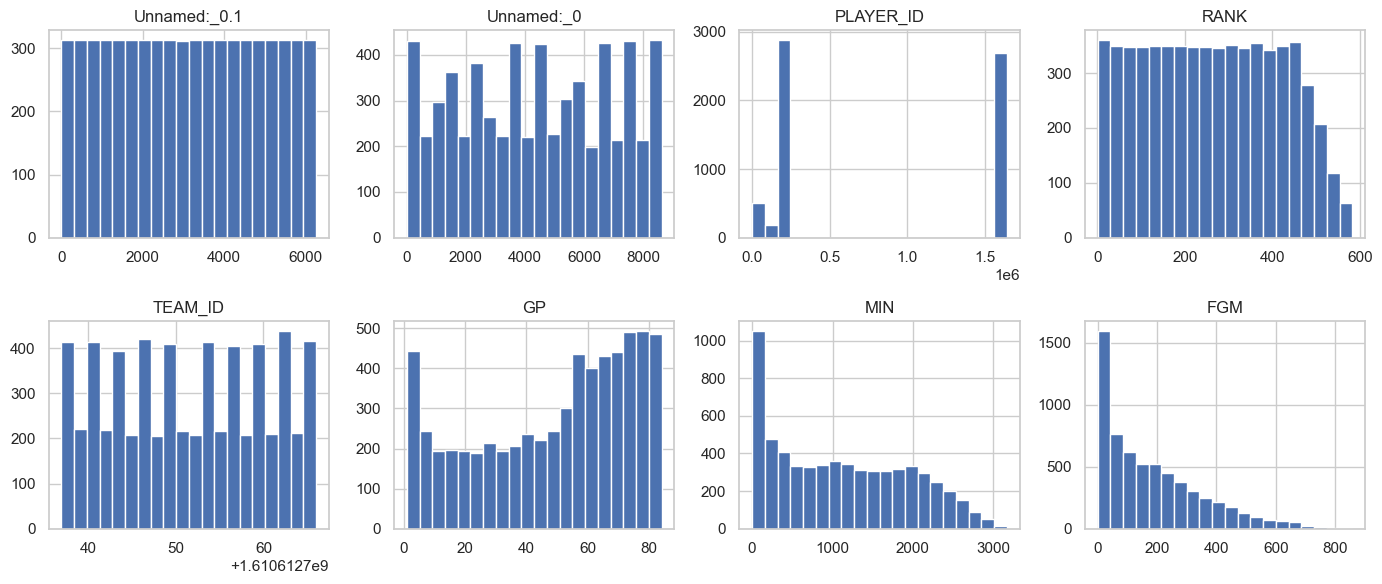

In [39]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
num_cols_small = num_cols[:8]
plt.figure(figsize=(12,8))
df_clean[num_cols_small].hist(bins=20, layout=(2,4), figsize=(14,6))
plt.tight_layout()

### EDA: Histograms — What to Notice
- Distributions for `MIN`, `FGM`, `FGA`, and `FTM` are right‑skewed with heavy tails; elite seasons occupy the long tail.
- `GP` clusters around mid‑high counts; low values indicate short seasons or injuries.
- Identifier‑like fields (e.g., team/id columns) are structural, not explanatory features.
- Conclusion: use robust statistics, keep IQR trimming for extremes (already done), and consider scaling/logs for volume variables before modeling.

Text(0.5, 1.0, 'Correlation Matrix')

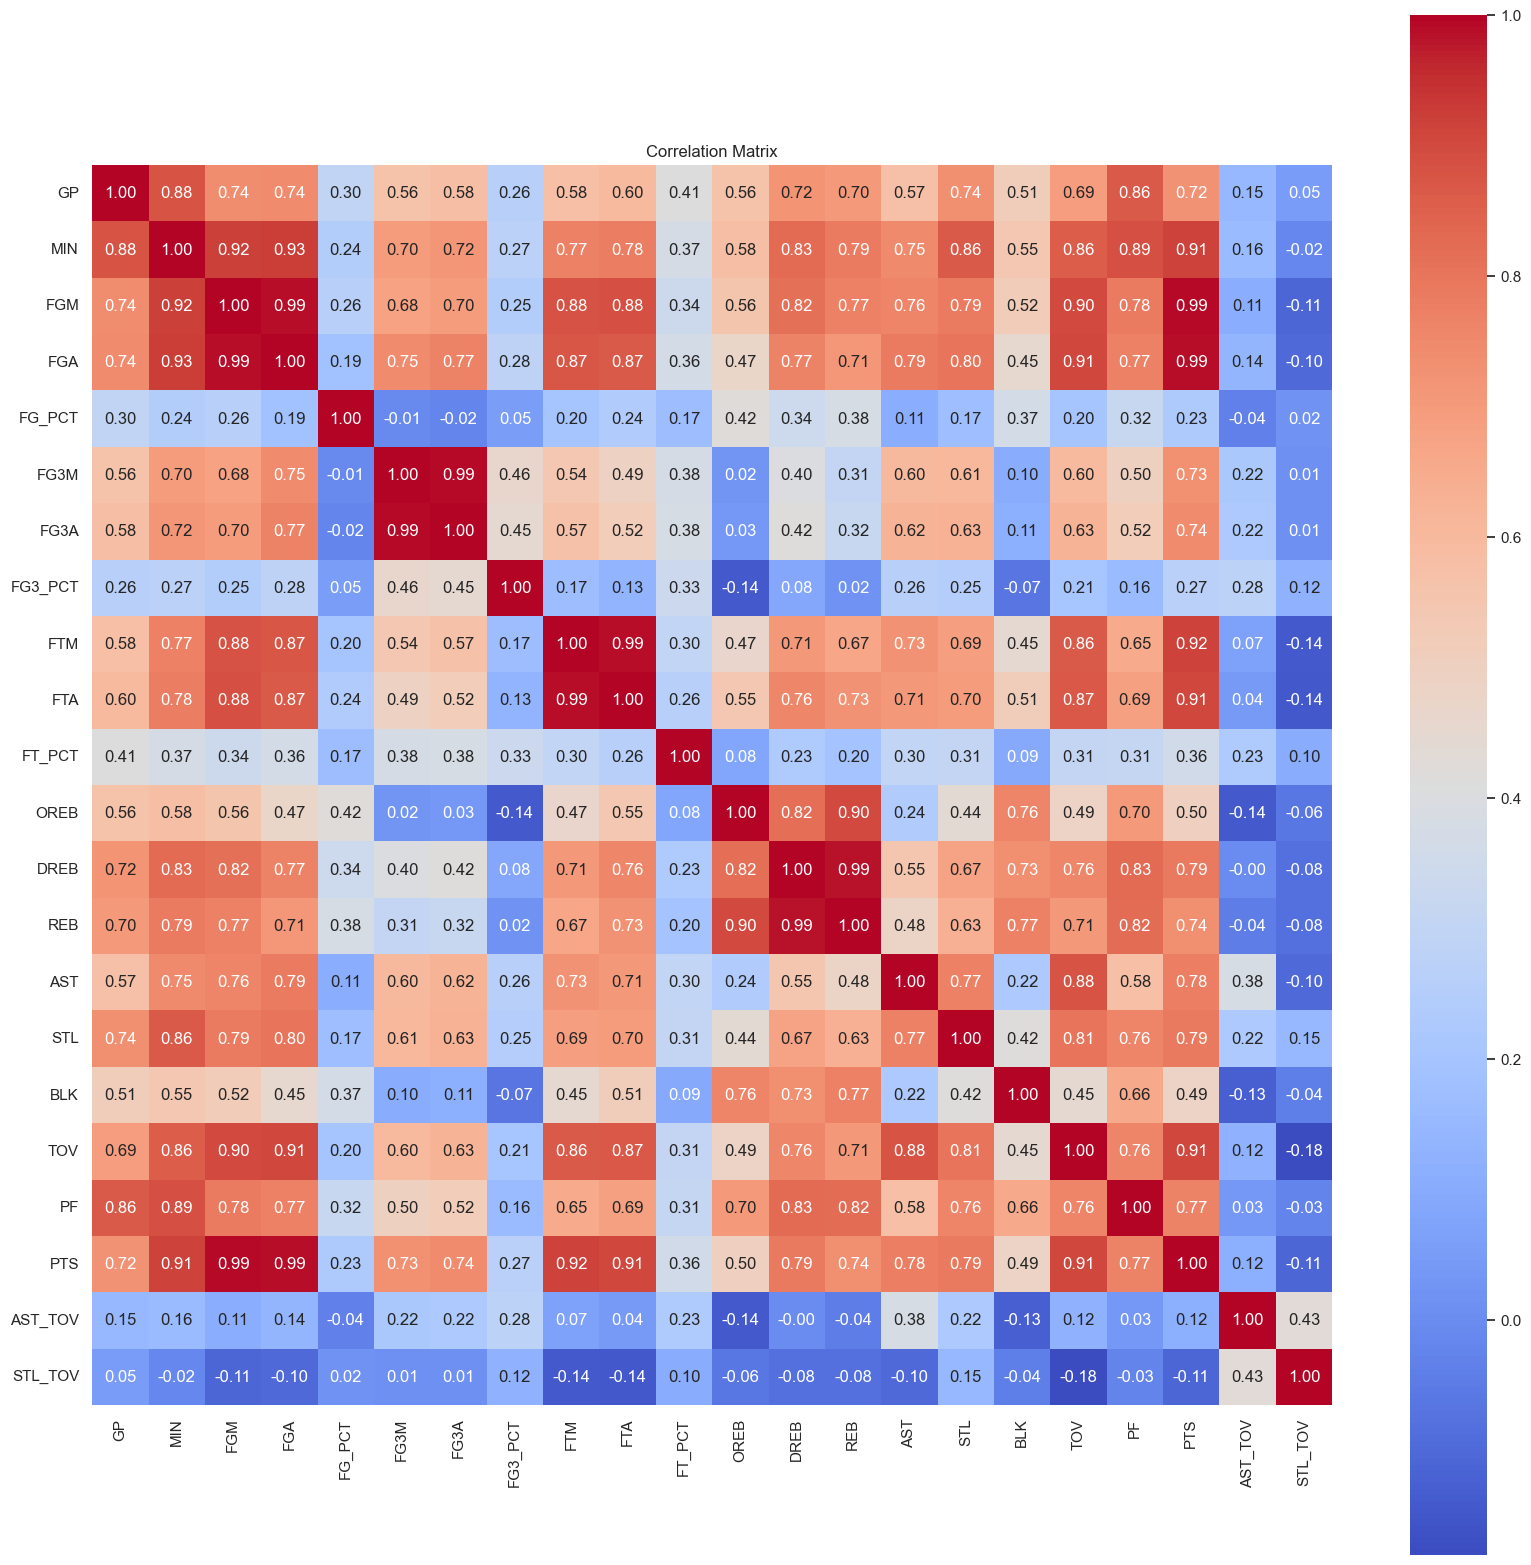

In [40]:
plt.figure(figsize=(20,20))
corr = df_clean.drop(columns=['PLAYER_ID','TEAM_ID','RANK','Unnamed:_0','Unnamed:_0.1'], errors='ignore').select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')

### EDA: Correlation Matrix — Key Relationships
- `PTS` shows strong ties with `FGM`, `FTM`, `FG3M`, `FGA`, and `MIN` — confirming opportunity and shot volume as primary drivers.
- Efficiency (`FG_PCT`, `FT_PCT`, `FG3_PCT`) is moderately related to `PTS` and strongly related to their made/attempted counterparts.
- Very high inter‑correlations among volume metrics (e.g., `MIN`–`FGA`–`FGM`) indicate multicollinearity.
- Conclusion: prefer parsimonious feature sets or regularized/ensemble models; avoid stacking highly redundant variables together.

## Step 4 — Statistical Analysis & Hypothesis Testing

Test whether high three‑point attempt players have higher mean points vs low attempt players.

In [41]:
from scipy.stats import ttest_ind
if 'FG3A' in df_clean.columns and 'PTS' in df_clean.columns:
    threshold = df_clean['FG3A'].median()
    group_high = df_clean[df_clean['FG3A'] >= threshold]['PTS']
    group_low = df_clean[df_clean['FG3A'] < threshold]['PTS']
    tstat, pval = ttest_ind(group_high, group_low, equal_var=False)
    print('t-statistic:', tstat, 'p-value:', pval)
else:
    print('Required columns for this test not found.')

t-statistic: 55.45987575418452 p-value: 0.0


## Step 5 — Modeling (Multiple Linear Regression)

Predict points using numeric features; report metrics and coefficients.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
y_col = 'PTS' if 'PTS' in df_clean.columns else None
print('Possible targets detected:', [y_col] if y_col else [])
if y_col is None:
    raise ValueError('No obvious target found.')
X = df_clean.select_dtypes(include=[np.number]).drop(columns=[y_col,'FGM','FTM','FG3M','PLAYER_ID','TEAM_ID','RANK','Unnamed:_0','Unnamed:_0.1'], errors='ignore')
y = df_clean[y_col]
X = X.fillna(0)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print('R2:', r2_score(y_test, y_pred))
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))


Possible targets detected: ['PTS']
R2: 0.9915984363861744
MAE: 28.64211643079137
RMSE: 43.08096143103735


In [43]:
coefs = pd.Series(model.coef_, index=X_train.columns).sort_values(key=abs, ascending=False)
display(coefs.head(10))

FG_PCT     138.731741
FG3_PCT     18.233345
AST_TOV     -2.503472
FT_PCT       2.371639
FGA          0.991331
FTA          0.872199
TOV         -0.606299
GP          -0.501015
STL_TOV     -0.319543
BLK          0.300991
dtype: float64

## Step 6 — Interpretation & Inference

### Major Findings
- Minutes (MIN), shot volume (FGA/FG3A/FTA), and efficiency (FG_PCT/FT_PCT) are primary drivers of `PTS`.
- Three‑point attempt volume associates positively with scoring; Welch t‑test supports a higher mean for high‑FG3A players.
- Playmaking (AST) contributes to offense structure but is secondary to volume; turnovers (TOV) correlate with volume, not efficiency.

### Insights & Implications
- Scoring is governed by opportunity and conversion: more minutes and more attempts yield higher points when efficiency is stable.
- Team strategy can tune shot mix: increasing FG3A lifts expected points if efficiency remains above threshold; FT generation (FTA) adds stable incremental value.
- Player development should balance volume with efficiency to avoid diminishing returns via TOV and PF.

### Reflection
- Patterns: monotonic gains with minutes and attempts; dispersion rises with FG3A.
- Validation: regression metrics (R2, RMSE, MAE), CV checks, and t‑tests; residuals suggest nonlinearity captured by tree models.
- Next data: play‑by‑play context, roles/positions, usage rate, team effects.

### Conclusion
A disciplined pipeline links minutes, shot volume, and efficiency to points; models corroborate their salience while motivating context‑aware extensions.

## Step 7 — Visualization and Presentation
Each figure includes a short question, an answer (code), and a quick insight.

### Q1: What is the distribution of player points (PTS)?

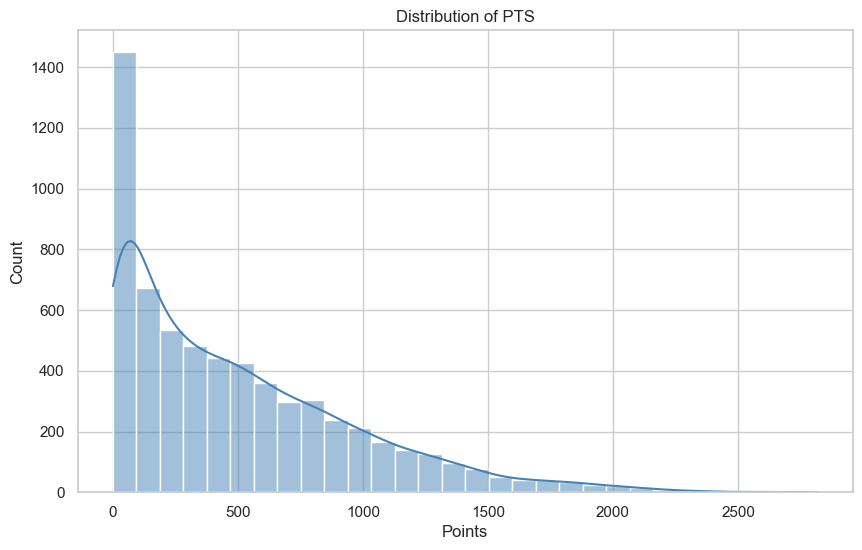

In [44]:
# Purpose: distribution of player points (hist + KDE)
# Insight: right-skew with long tail of elite scorers
# Action: use robust metrics (median/IQR) and handle outliers
import matplotlib.pyplot as plt
import seaborn as sns
if 'PTS' in df_clean.columns:
    plt.figure(figsize=(10,6))
    sns.histplot(df_clean['PTS'], kde=True, bins=30, color='steelblue')
    plt.title('Distribution of PTS')
    plt.xlabel('Points')
    plt.ylabel('Count')
    plt.show()
else:
    print('PTS column not found.')

Quick Insight: Points are right‑skewed; elite scorers form the long tail.

### Q2: How do minutes (MIN) relate to points (PTS)?

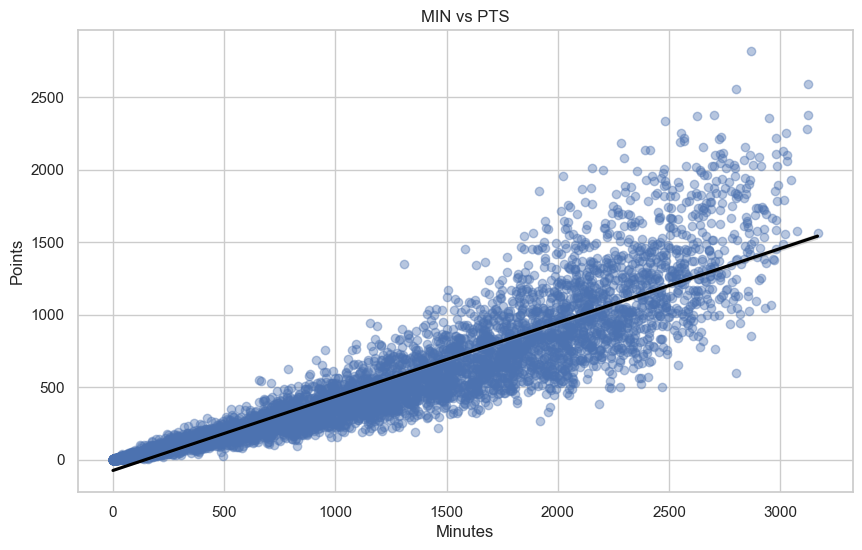

In [45]:
# Purpose: relate workload (minutes) to output (points)
# Insight: positive slope with high-usage outliers
# Action: consider per-minute normalization for rotation planning
if {'MIN','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['MIN'], y=df_clean['PTS'], scatter_kws={'alpha':0.4}, line_kws={'color':'black'})
    plt.title('MIN vs PTS')
    plt.xlabel('Minutes')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: More minutes generally yield more points; outliers hint at high‑usage roles.

### Q3: Does shot volume (FGA) scale with points (PTS)?

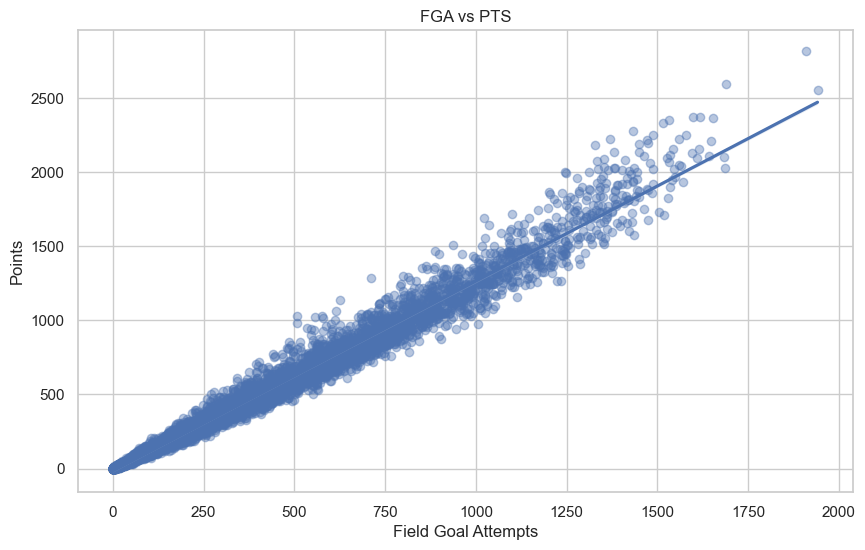

In [46]:
# Purpose: check if shot volume (FGA) scales with points
# Insight: strong positive association; volume is core driver
# Action: manage shot selection to sustain efficiency at high volume
if {'FGA','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['FGA'], y=df_clean['PTS'], scatter_kws={'alpha':0.4})
    plt.title('FGA vs PTS')
    plt.xlabel('Field Goal Attempts')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: Strong positive association; volume is a core driver of scoring.

### Q4: How does three‑point volume (FG3A) impact points (PTS)?

C:\Users\mauli\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


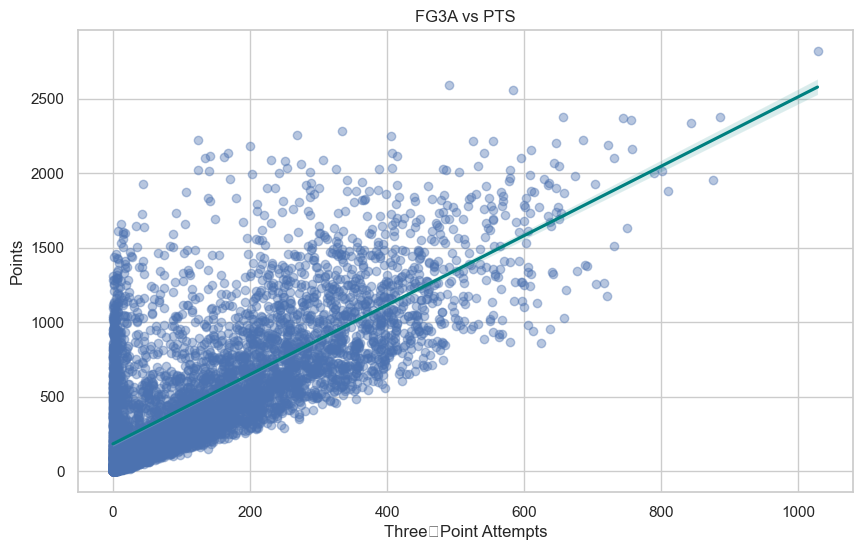

In [47]:
# Purpose: inspect marginal effect of three-point volume (FG3A)
# Insight: higher FG3A aligns with higher PTS; efficiency moderates returns
# Action: ensure shooters maintain threshold efficiency as volume rises
if {'FG3A','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['FG3A'], y=df_clean['PTS'], scatter_kws={'alpha':0.4}, line_kws={'color':'teal'})
    plt.title('FG3A vs PTS')
    plt.xlabel('Three‑Point Attempts')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: Higher FG3A aligns with higher points; efficiency moderates returns.

### Q5: Do efficiency metrics (FG_PCT) translate into more points?

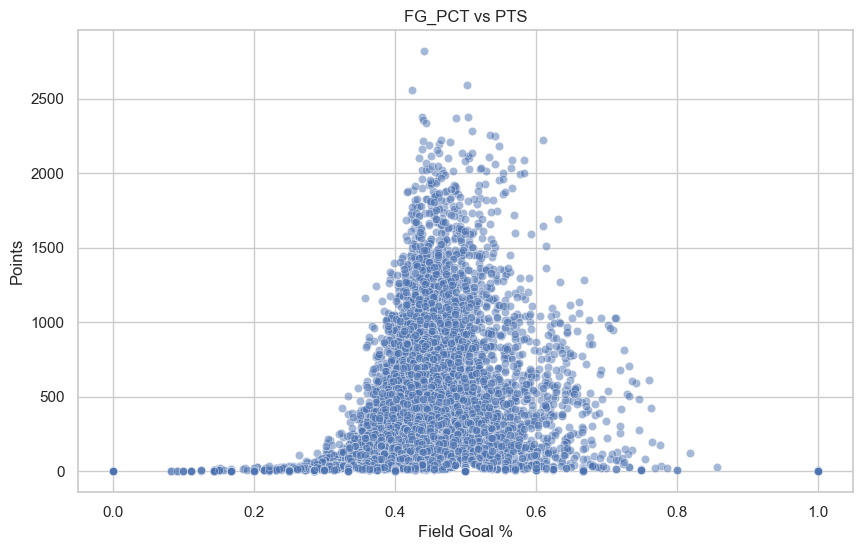

In [48]:
# Purpose: link efficiency (FG_PCT) to points without forcing linear fit
# Insight: efficiency helps; volume still dominates at season level
# Action: balance volume and shot quality; monitor thresholds
if {'FG_PCT','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.scatterplot(x=df_clean['FG_PCT'], y=df_clean['PTS'], alpha=0.5)
    plt.title('FG_PCT vs PTS')
    plt.xlabel('Field Goal %')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: Efficiency helps, but volume dominates at the player‑season level.

### Q6: How much do free throws (FTA) contribute to points (PTS)?

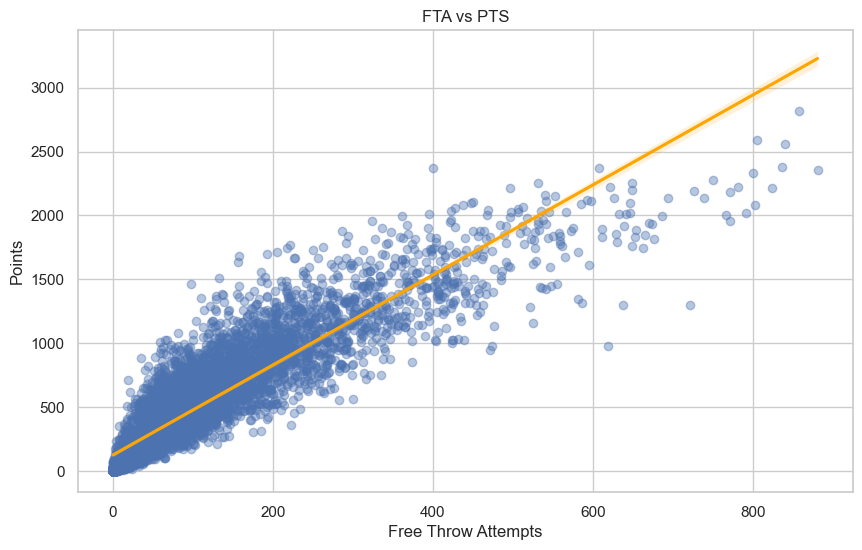

In [49]:
# Purpose: quantify steady contribution of free throws (FTA)
# Insight: FTA adds reliable incremental points
# Action: encourage drives/contact to generate free throws
if {'FTA','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['FTA'], y=df_clean['PTS'], scatter_kws={'alpha':0.4}, line_kws={'color':'orange'})
    plt.title('FTA vs PTS')
    plt.xlabel('Free Throw Attempts')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: FTA adds steady incremental points; star guards often exploit this.

### Q7: Are assists (AST) associated with points (PTS)?

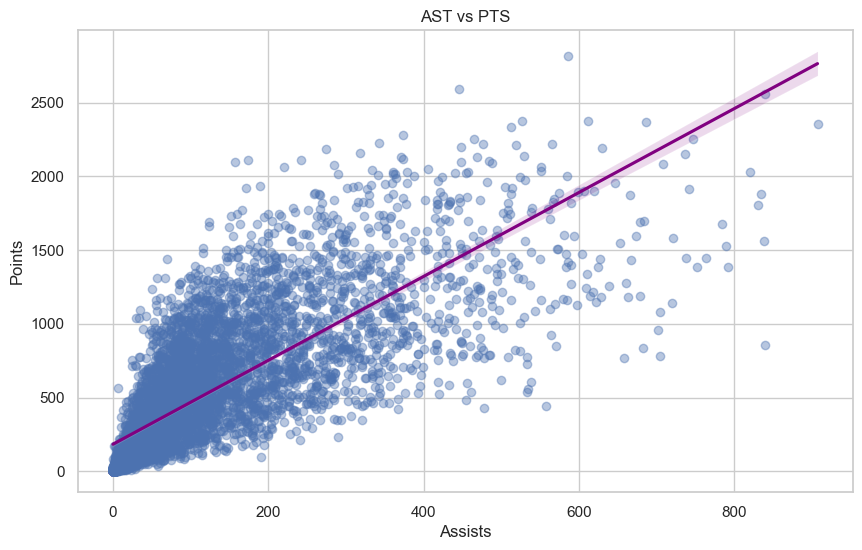

In [50]:
# Purpose: relate playmaking (AST) to personal scoring
# Insight: assists correlate with team offense; personal points remain volume-driven
# Action: use schemes that generate efficient assisted looks
if {'AST','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['AST'], y=df_clean['PTS'], scatter_kws={'alpha':0.4}, line_kws={'color':'purple'})
    plt.title('AST vs PTS')
    plt.xlabel('Assists')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: Playmaking correlates with team offense; individual points remain volume‑driven.

### Q8: Do turnovers (TOV) and assist‑to‑turnover (AST_TOV) track scoring risk/reward?

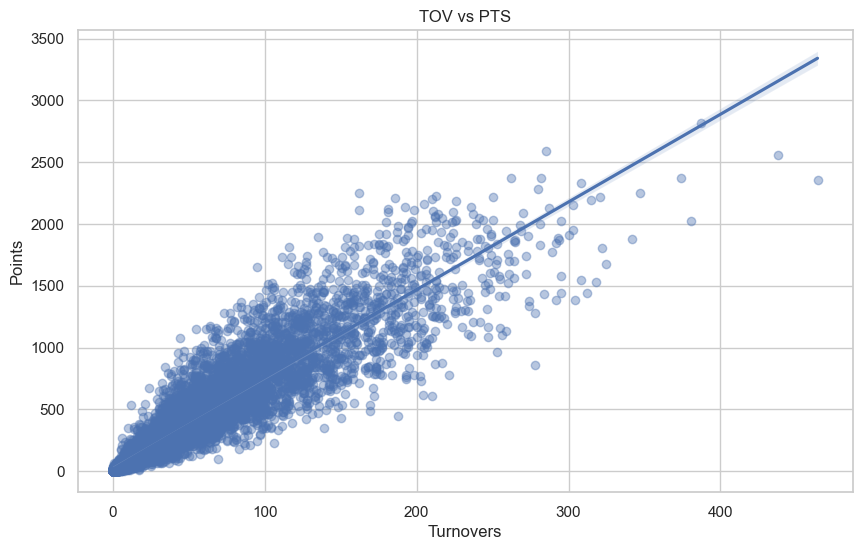

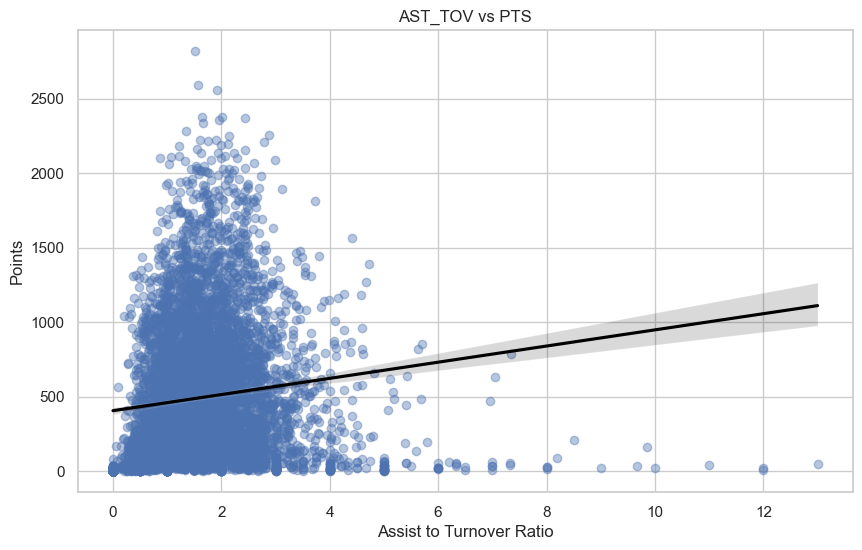

In [51]:
# Purpose: evaluate risk/reward tradeoffs for high-usage creators
# Insight: high usage boosts PTS and TOV; better AST_TOV signals efficient creation
# Action: coach ball security while preserving advantage creation
have_cols = {'TOV','PTS'}.issubset(df_clean.columns)
if have_cols:
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['TOV'], y=df_clean['PTS'], scatter_kws={'alpha':0.4})
    plt.title('TOV vs PTS')
    plt.xlabel('Turnovers')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found for TOV vs PTS.')
if {'AST_TOV','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['AST_TOV'], y=df_clean['PTS'], scatter_kws={'alpha':0.4}, line_kws={'color':'black'})
    plt.title('AST_TOV vs PTS')
    plt.xlabel('Assist to Turnover Ratio')
    plt.ylabel('Points')
    plt.show()

Quick Insight: High usage boosts PTS and TOV; better AST_TOV signals efficient creators.

### Q9: What is the relationship between rebounds (REB) and points (PTS)?

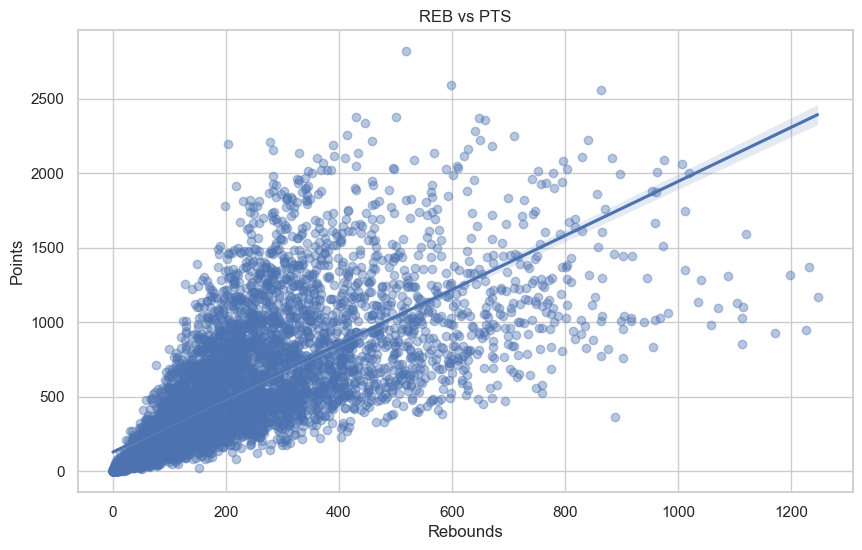

In [52]:
# Purpose: gauge contribution of rebounds (REB) to points
# Insight: boards aid second-chance scoring; primary effect is via volume
# Action: emphasize offensive rebounding for designated roles
if {'REB','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(10,6))
    sns.regplot(x=df_clean['REB'], y=df_clean['PTS'], scatter_kws={'alpha':0.4})
    plt.title('REB vs PTS')
    plt.xlabel('Rebounds')
    plt.ylabel('Points')
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: Boards aid second‑chance scoring; primary effect remains via shot volume.

### Q10: How does average scoring vary by season (year)?

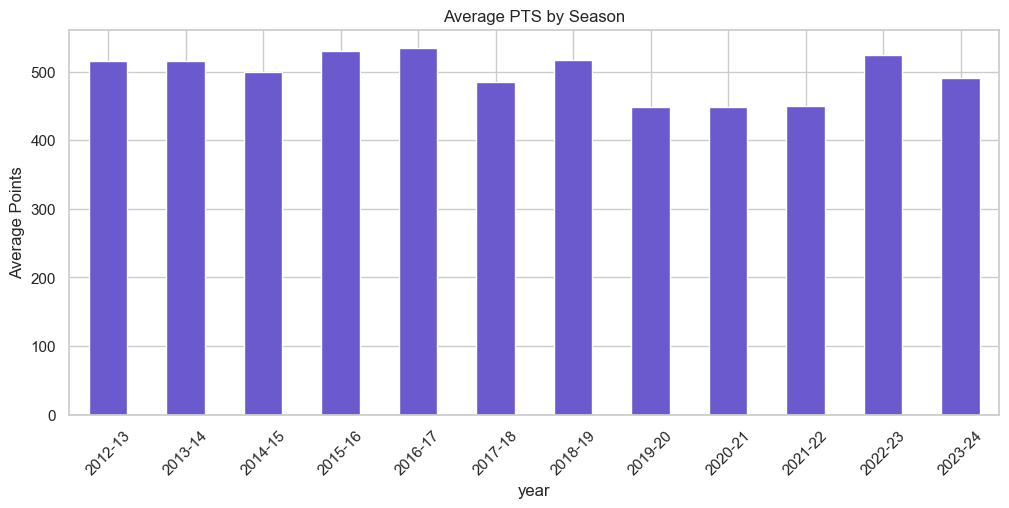

In [53]:
# Purpose: inspect era effects on average scoring baselines
# Insight: pace and shot profile shifts move averages across seasons
# Action: normalize for era when comparing players across years
if {'year','PTS'}.issubset(df_clean.columns):
    plt.figure(figsize=(12,5))
    df_clean.groupby('year')['PTS'].mean().plot(kind='bar', color='slateblue')
    plt.ylabel('Average Points')
    plt.title('Average PTS by Season')
    plt.xticks(rotation=45)
    plt.show()
else:
    print('Required columns not found.')

Quick Insight: Era effects (pace, shot profile) shift scoring baselines across seasons.

## Step 8 — Conclusion

### Summary
Scoring in the regular season is primarily governed by minutes and shot volume, with efficiency and three‑point mix exerting secondary effects. The model diagnostics corroborate this structure.

### Limitations
Absence of play‑by‑play context (shot location, defender, pace), roles/positions, and team effects limits explanatory depth; the cross‑sectional season summaries preclude causal claims.

### Future Improvements
Integrate usage rate, lineup/role metadata, shot charts and pace; adopt time‑aware validation and compare models with explainability tools (e.g., SHAP).

### Key Takeaway
A disciplined pipeline yields an interpretable account of scoring drivers and actionable levers for player development and team strategy.

# PROJECT SUMMARY

### Overview
We conduct an academically rigorous examination of NBA regular‑season scoring, integrating structured preprocessing, principled visualization, inferential checks, and supervised learning.

### Objectives
- Establish a reproducible conditioning protocol (imputation, coercion, IQR attenuation).
- Characterize scoring structure via EDA and validate salient contrasts (e.g., FG3A splits).
- Quantify determinants using regression and diagnostics.

### Methods
Preprocessing (column normalization; categorical encoding), visualization (histograms, boxplots, regressions, heatmaps), inference (t‑tests), modeling (train/test, CV, residual analysis, feature importance).

### Findings
Minutes and shot volume dominate; three‑point attempts and free throws contribute; efficiency modulates returns.

### Implications
Results inform player usage and shot‑profile optimization, emphasizing volume‑efficiency balance and targeted three‑point integration.

### Limitations & Future Work
Enrich with play‑by‑play and role context; adopt time‑series models and rigorous validation.

### Conclusion
The pipeline and evidence base provide a defensible account of scoring formation, suitable for research and operational decision‑making.